In [2]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import Angle
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

In [3]:
data_folder = 'ADP_FLAMES_30Dor_30arcmin'

In [4]:
fits_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor") / data_folder

In [5]:
c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [6]:
#fov_deg = 1.0  # Total field of view in degrees (width and height)
#pix_scale = 1 / 3600
#npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
#wcs.wcs.crpix = [npix, npix]  # center of your "image"
#wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [7]:
from pathlib import Path
import pickle

base_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor")
pickle_path = base_dir / "flames30dor_dataframes.pkl"

with open(pickle_path, "rb") as f:
    df_dict = pickle.load(f)

df = df_dict["df"]
df_letter = df_dict["df_letter"]
df_pos = df_dict["df_pos"]
df_num = df_dict["df_num"]

print(df_dict.keys())
print(df_letter.head())

dict_keys(['df', 'df_letter', 'df_pos', 'df_num'])
                              filename object                 date_obs  \
2336  ADP.2019-01-31T23_53_42.007.fits    t60  2003-12-03T03:42:56.961   
2337  ADP.2019-01-31T23_53_42.024.fits    t29  2003-12-03T05:54:18.706   
2338  ADP.2019-01-31T23_53_42.039.fits    u37  2003-12-03T01:44:39.244   
2339  ADP.2019-01-31T23_53_42.048.fits    t56  2003-12-03T01:44:39.244   
2341  ADP.2019-01-31T23_53_42.079.fits    u10  2003-12-03T03:42:56.961   

           mjd_obs instrument   telescope                           arcfile  \
2336  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.007.fits   
2337  52976.246050    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.024.fits   
2338  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.039.fits   
2339  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.048.fits   
2341  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.079.fits   

            prog_id          

# Iregular grid

In [9]:
df_pos

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group
0,ADP.2015-07-21T08_02_25.090.fits,pos098,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:25.090.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.821958,-69.028556,599.9880,600.0,pos098_ra84.821958_dec-69.028556_exp600.0,pos_digits
1,ADP.2015-07-21T08_02_25.867.fits,pos103,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:25.867.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.719625,-69.205111,599.9880,600.0,pos103_ra84.719625_dec-69.205111_exp600.0,pos_digits
2,ADP.2015-07-21T08_02_26.550.fits,pos082,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:26.550.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.655292,-69.060250,599.9880,600.0,pos082_ra84.655292_dec-69.06025_exp600.0,pos_digits
3,ADP.2015-07-21T08_02_26.837.fits,pos045,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:26.837.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.766708,-69.131056,599.9880,600.0,pos045_ra84.766708_dec-69.131056_exp600.0,pos_digits
4,ADP.2015-07-21T08_02_27.470.fits,pos006,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:27.470.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.725042,-69.092389,599.9880,600.0,pos006_ra84.725042_dec-69.092389_exp600.0,pos_digits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3610,ADP.2019-05-20T15_43_46.639.fits,pos032,2003-12-03T08:50:44.526,52976.368571,GIRAFFE,ESO-VLT-U2,ADP.2019-05-20T15:43:46.639.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.676792,-69.117861,599.9858,600.0,pos032_ra84.676792_dec-69.117861_exp600.0,pos_digits
3614,ADP.2019-05-20T15_43_46.647.fits,pos028,2003-12-03T08:50:44.526,52976.368571,GIRAFFE,ESO-VLT-U2,ADP.2019-05-20T15:43:46.647.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.523000,-69.077972,599.9858,600.0,pos028_ra84.523_dec-69.077972_exp600.0,pos_digits
3615,ADP.2019-05-20T15_43_46.649.fits,pos030,2003-12-03T08:50:44.526,52976.368571,GIRAFFE,ESO-VLT-U2,ADP.2019-05-20T15:43:46.649.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.485000,-69.096639,599.9858,600.0,pos030_ra84.485_dec-69.096639_exp600.0,pos_digits
3617,ADP.2019-05-20T15_43_46.653.fits,pos001,2003-12-03T08:50:44.526,52976.368571,GIRAFFE,ESO-VLT-U2,ADP.2019-05-20T15:43:46.653.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.687667,-69.086000,599.9858,600.0,pos001_ra84.687667_dec-69.086_exp600.0,pos_digits


# Plot data points

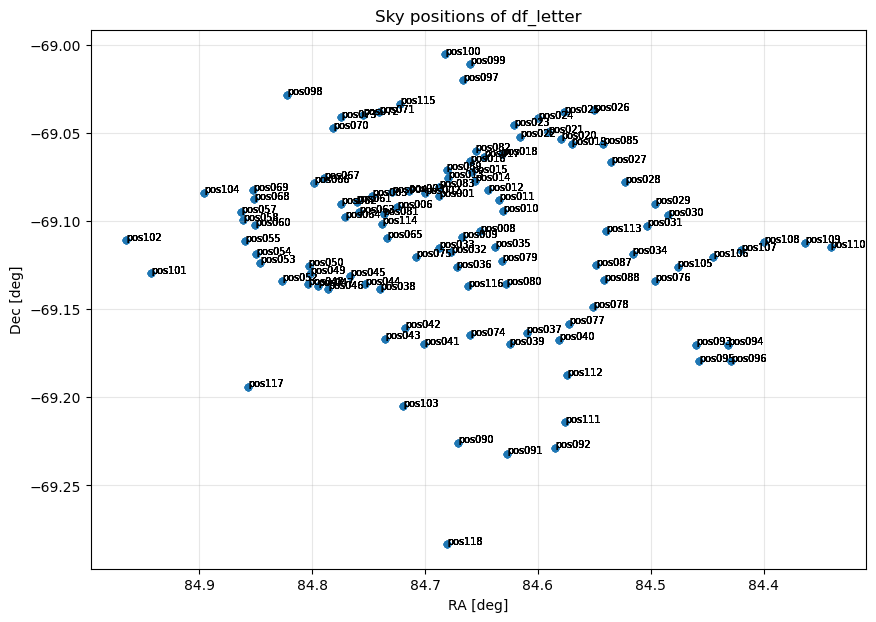

In [10]:
df_plot = df_pos.dropna(subset=["ra_deg", "dec_deg"]).copy()

plt.figure(figsize=(10, 7))
plt.scatter(df_plot["ra_deg"], df_plot["dec_deg"], s=20)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    plt.text(row["ra_deg"], row["dec_deg"], label, fontsize=7)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions of df_letter")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

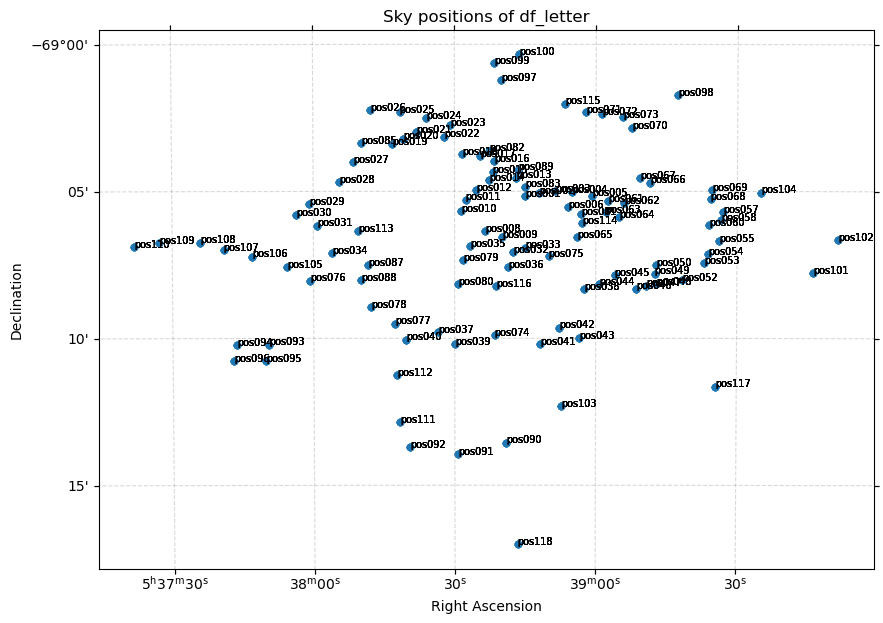

In [11]:
df_plot = df_pos.dropna(subset=["ra_deg", "dec_deg"]).copy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

ax.scatter(
    df_plot["ra_deg"],
    df_plot["dec_deg"],
    s=20,
    transform=ax.get_transform("world")
)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        transform=ax.get_transform("world")
    )

ax.set_title("Sky positions of df_letter")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")

plt.show()

Load spetra

In [14]:
from pathlib import Path
from astropy.io import fits

# Folder where the FITS files are stored

pos_spectra = []

for _, row in df_pos.iterrows():
    fits_path = fits_dir / row["filename"]

    try:
        with fits.open(fits_path) as hdul:
            spec = hdul[1].data

            wave = spec["WAVE"][0]
            flux = spec["FLUX_REDUCED"][0]
            err  = spec["ERR_REDUCED"][0]
#            snr  = spec["SNR"][0]

            pos_spectra.append({
                "filename": row["filename"],
                "object": row["object"],
                "ra_deg": row["ra_deg"],
                "dec_deg": row["dec_deg"],
                "wave": wave,
                "flux": flux,
                "err": err,
#                "snr": snr,
            })

    except Exception as e:
        print(f"Could not read {fits_path.name}: {e}")

print(f"Loaded {len(pos_spectra)} spectra from df_pos")

Loaded 784 spectra from df_letter


In [22]:
def plot_spectra_subset(spectra_list, wmin, wmax, normalize=False):
    plt.figure(figsize=(12, 6))

    for spec in spectra_list:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        wave_zoom = wave[mask]
        flux_zoom = flux[mask]

        if len(wave_zoom) == 0:
            continue

        if normalize and flux_zoom.max() != 0:
            flux_zoom = flux_zoom / flux_zoom.max()

        plt.plot(wave_zoom, flux_zoom, alpha=0.7, lw=1)

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Normalized Flux" if normalize else "Reduced Flux [adu]")
    plt.title(f"Spectra zoom: {wmin}–{wmax} nm")
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
#letter_spectra

In [13]:
#plot_spectra_subset(letter_spectra, 655, 658, normalize=True)

Export one PNG per spectrum

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

wmin = 655
wmax = 658

outdir = Path("plots_pos_zoom")
outdir.mkdir(exist_ok=True)

for spec in pos_spectra:
    wave = spec["wave"]
    flux = spec["flux"]
    mask = (wave >= wmin) & (wave <= wmax)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(wave[mask], flux[mask])
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Reduced Flux [adu]")
    ax.set_title(f"{spec['object']} | {spec['filename']} | {wmin}–{wmax} nm")
    ax.grid(True, alpha=0.3)

    obj = str(spec["object"]).replace("/", "_").replace("\\", "_").replace(" ", "_")
    base = Path(spec["filename"]).stem
    fname = outdir / f"{obj}_{base}_{wmin}_{wmax}.png"

    fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {len(pos_spectra)} plots in: {outdir.resolve()}")
plt.ioff()

Saved 784 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom


Script for one object family.

In [17]:
from pathlib import Path
import pandas as pd
from astropy.io import fits

# Example: only t01
df_pos001 = df_pos[df_pos["object"].astype(str).str.strip().str.lower() == "pos001"].copy()

keys = [
    "OBJECT",
    "DATE",
    "DATE-OBS",
    "MJD-OBS",
    "EXPTIME",
    "INSTRUME",
    "TELESCOP",
    "RA",
    "DEC",
    "ARCFILE",
    "HIERARCH ESO OBS PROG ID",
    "HIERARCH ESO OBS NAME",
    "HIERARCH ESO DPR CATG",
    "HIERARCH ESO DPR TYPE",
    "HIERARCH ESO DPR TECH",
    "HIERARCH ESO PRO CATG",
    "HIERARCH ESO PRO TECH",
    "HIERARCH ESO PRO REC1 ID",
    "HIERARCH ESO PRO REC1 PIPE ID",
    "HIERARCH ESO PRO REC1 RAW1 NAME",
]

rows = []

for _, row in df_pos001.iterrows():
    fpath = fits_dir / row["filename"]
    with fits.open(fpath) as hdul:
        hdr = hdul[0].header

    out = {"filename": row["filename"]}
    for k in keys:
        out[k] = hdr.get(k)
    rows.append(out)

df_pos001_hdr = pd.DataFrame(rows)
print(df_pos001_hdr)

                           filename  OBJECT                 DATE  \
0  ADP.2015-07-21T08_02_54.150.fits  pos001  2015-05-08T22:21:09   
1  ADP.2019-01-31T23_21_56.029.fits  pos001  2018-12-12T00:01:09   
2  ADP.2019-01-31T23_21_56.545.fits  pos001  2018-12-11T23:59:08   
3  ADP.2019-01-31T23_53_42.332.fits  pos001  2018-12-11T23:55:37   
4  ADP.2019-01-31T23_53_45.084.fits  pos001  2018-12-11T23:53:36   
5  ADP.2019-01-31T23_53_45.261.fits  pos001  2018-12-11T23:51:36   
6  ADP.2019-05-20T15_43_46.653.fits  pos001  2019-03-13T15:19:44   

                  DATE-OBS       MJD-OBS    EXPTIME INSTRUME    TELESCOP  \
0  2003-12-03T09:05:37.450  52976.378906   599.9880  GIRAFFE  ESO-VLT-U2   
1  2003-12-04T01:57:44.489  52977.081765  1199.9600  GIRAFFE  ESO-VLT-U2   
2  2003-12-04T01:29:47.948  52977.062361  1199.9611  GIRAFFE  ESO-VLT-U2   
3  2003-12-03T08:13:17.621  52976.342565  1799.9619  GIRAFFE  ESO-VLT-U2   
4  2003-12-03T07:36:20.171  52976.316900  1799.9601  GIRAFFE  ESO-VLT-U2   

In [18]:
cols = [
    "filename",
    "DATE-OBS",
    "EXPTIME",
    "RA",
    "DEC",
    "HIERARCH ESO OBS NAME",
    "HIERARCH ESO PRO CATG",
    "HIERARCH ESO PRO REC1 PIPE ID",
    "HIERARCH ESO PRO REC1 RAW1 NAME",
]

df_pos001_hdr[cols].sort_values("DATE-OBS")

,filename,DATE-OBS,EXPTIME,RA,DEC,HIERARCH ESO OBS NAME,HIERARCH ESO PRO CATG,HIERARCH ESO PRO REC1 PIPE ID,HIERARCH ESO PRO REC1 RAW1 NAME
5,ADP.2019-01-31T23_53_45.261.fits,2003-12-03T06:59:35.192,1799.9595,84.687667,-69.086,30Dor_Fil,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-03T07:21:21.087.fits
4,ADP.2019-01-31T23_53_45.084.fits,2003-12-03T07:36:20.171,1799.9601,84.687667,-69.086,30Dor_Fil,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-03T07:58:05.306.fits
3,ADP.2019-01-31T23_53_42.332.fits,2003-12-03T08:13:17.621,1799.9619,84.687667,-69.086,30Dor_Fil,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-03T08:35:03.377.fits
6,ADP.2019-05-20T15_43_46.653.fits,2003-12-03T08:50:44.526,599.9858,84.687667,-69.086,30Dor_Fil,SCIENCE_RBNSPEC_IDP,giraf/2.16.3,GIRAF.2003-12-03T08:50:44.527_PC_clean.fits
0,ADP.2015-07-21T08_02_54.150.fits,2003-12-03T09:05:37.450,599.9880,84.687667,-69.086,30Dor_Fil,SCIENCE_RBNSPEC_IDP,giraf/2.14.1,GIRAF.2003-12-03T09:05:37.450.fits
2,ADP.2019-01-31T23_21_56.545.fits,2003-12-04T01:29:47.948,1199.9611,84.687667,-69.086,30Dor_Fil-S2,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-04T01:40:41.066.fits
1,ADP.2019-01-31T23_21_56.029.fits,2003-12-04T01:57:44.489,1199.9600,84.687667,-69.086,30Dor_Fil-S2,SCIENCE_RBNSPEC_STACK,giraf/2.16.3,GIRAF.2003-12-04T02:08:36.927.fits


In [19]:
pos001_spectra = [spec for spec in pos_spectra if str(spec["object"]).strip().lower() == "pos001"]

In [25]:
pos002_spectra = [spec for spec in pos_spectra if str(spec["object"]).strip().lower() == "pos002"]

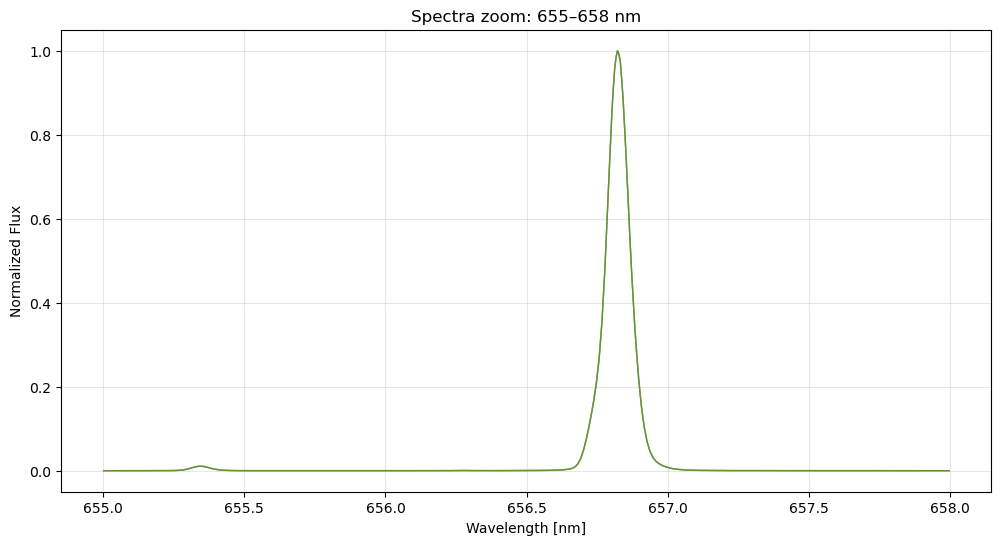

In [26]:
plot_spectra_subset(pos002_spectra, 655, 658, normalize=True)

In [42]:
df_pos["EXPTIME"].value_counts().sort_index()

EXPTIME
599.9858     112
599.9880     112
1199.9600    112
1199.9611    112
1799.9595    112
1799.9601    112
1799.9619    112
Name: count, dtype: int64

# Sample Long EXPTIME

In [55]:
df_expX = df_pos[df_pos["EXPTIME"] == 599.9858].copy()
df_expY = df_pos[df_pos["EXPTIME"] == 599.9880].copy()

In [56]:
df_plotX = df_expX.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotY = df_expY.dropna(subset=["ra_deg", "dec_deg"]).copy()

In [57]:
dfs = {
    "X": df_plotA,
    "Y": df_plotB,
}

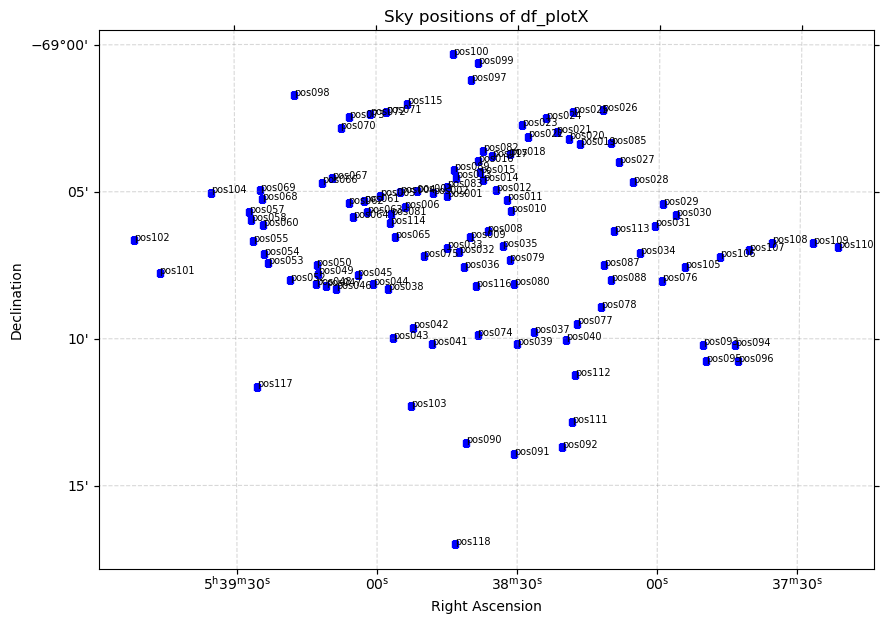

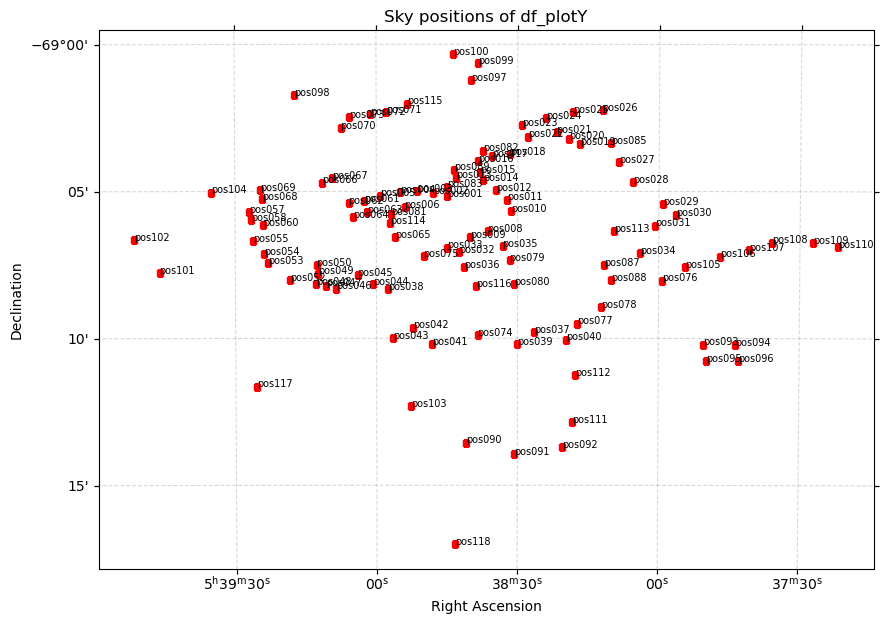

In [58]:
colors = ["blue", "red", "green", "orange", "purple"]

for (name, df_plot), color in zip(dfs.items(), colors):
    plot_sky_positions(df_plot, wcs, title=f"Sky positions of df_plot{name}", color=color)

# Sample Long EXPTIME

In [44]:
df_expA = df_pos[df_pos["EXPTIME"] == 1199.9600].copy()
df_expB = df_pos[df_pos["EXPTIME"] == 1199.9611].copy()
df_expC = df_pos[df_pos["EXPTIME"] == 1799.9595].copy()
df_expD = df_pos[df_pos["EXPTIME"] == 1799.9601].copy()
df_expE = df_pos[df_pos["EXPTIME"] == 1799.9619].copy()

In [45]:
df_plotA = df_expA.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotB = df_expB.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotC = df_expC.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotD = df_expB.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotE = df_expC.dropna(subset=["ra_deg", "dec_deg"]).copy()

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_sky_positions(df_plot, wcs, title="Sky positions", color="blue", marker="s", size=20, fontsize=7):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    ax.scatter(
        df_plot["ra_deg"],
        df_plot["dec_deg"],
        s=size,
        marker=marker,
        color=color,
        transform=ax.get_transform("world")
    )

    for _, row in df_plot.iterrows():
        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
        ax.text(
            row["ra_deg"],
            row["dec_deg"],
            label,
            fontsize=fontsize,
            transform=ax.get_transform("world")
        )

    ax.set_title(title)
    ax.coords[0].set_axislabel("Right Ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.grid(color="gray", alpha=0.3, linestyle="--")
    ax.invert_xaxis()

    plt.show()

In [53]:
dfs = {
    "A": df_plotA,
    "B": df_plotB,
    "C": df_plotC,
    "D": df_plotD,
    "E": df_plotE,
}

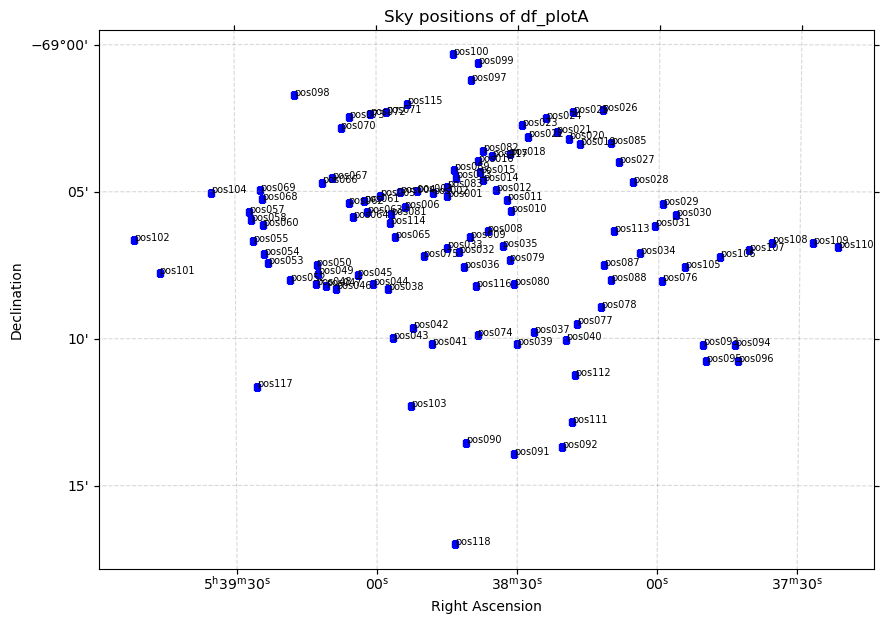

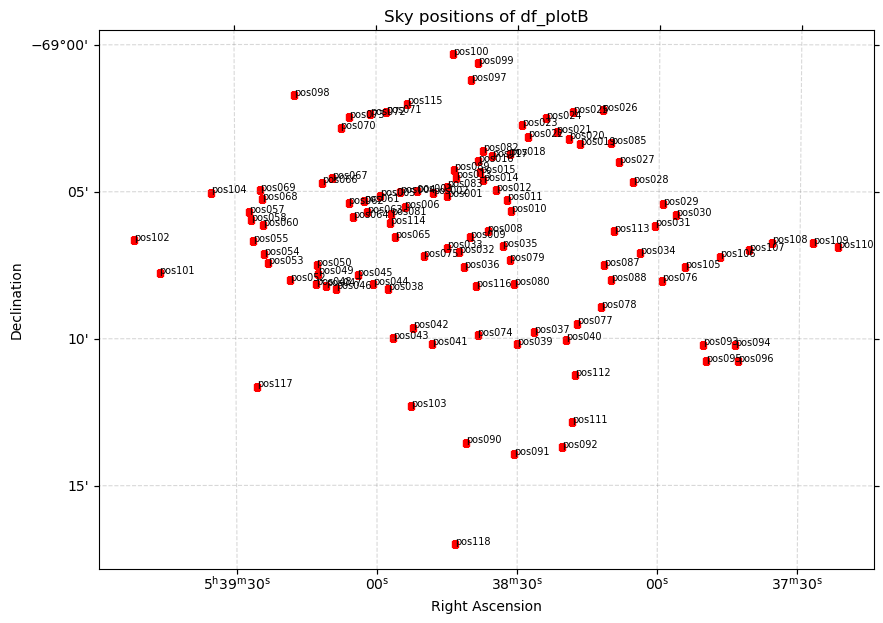

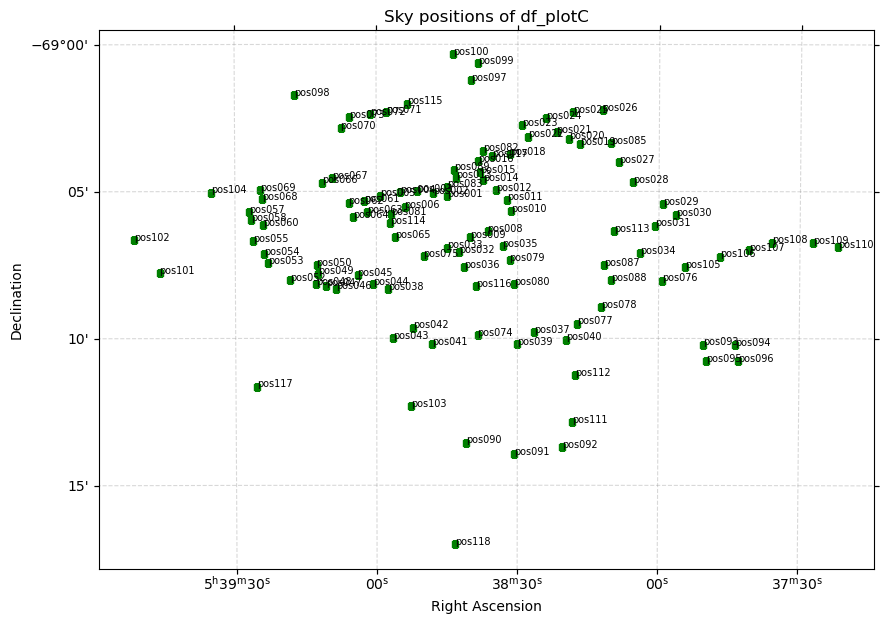

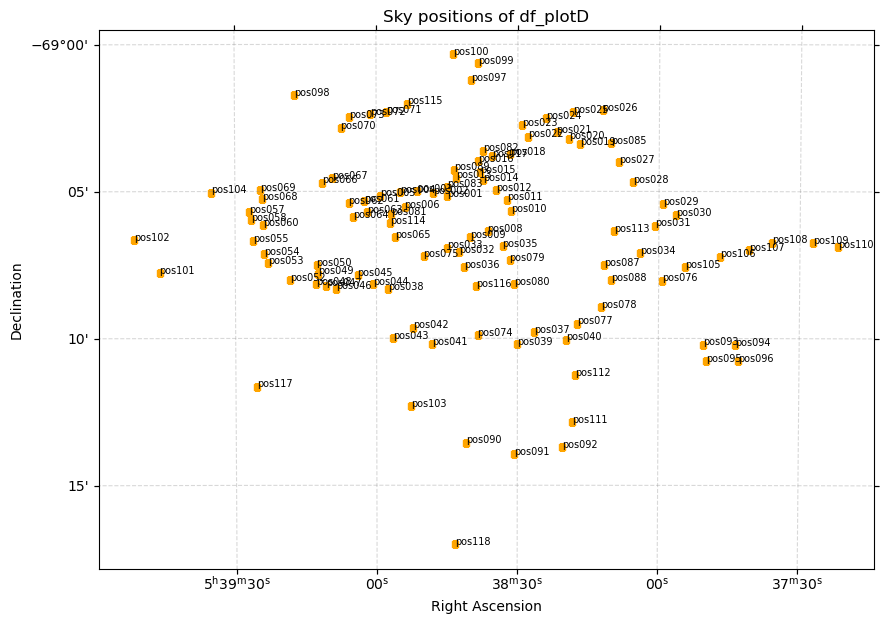

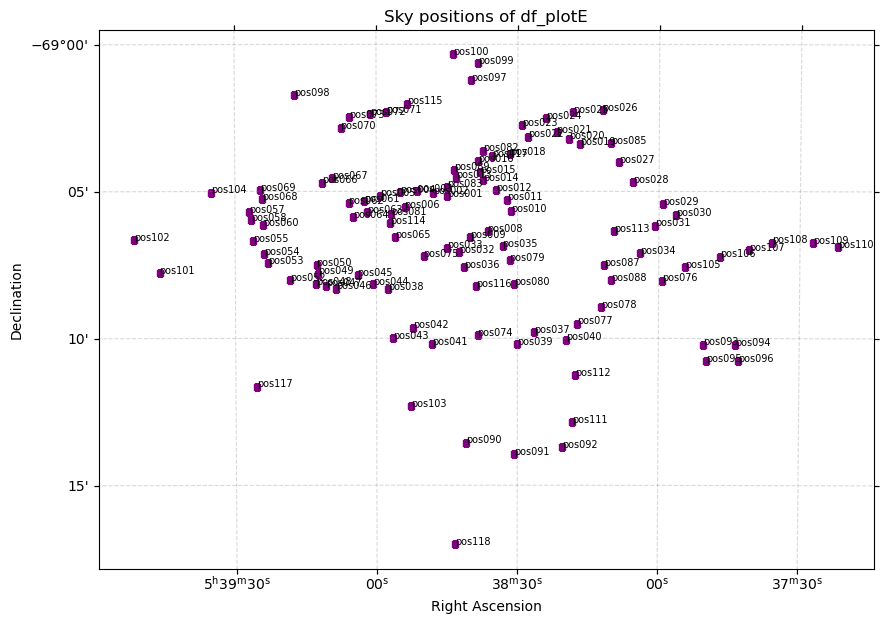

In [54]:
colors = ["blue", "red", "green", "orange", "purple"]

for (name, df_plot), color in zip(dfs.items(), colors):
    plot_sky_positions(df_plot, wcs, title=f"Sky positions of df_plot{name}", color=color)

# Data EXPTIME samples

Load spectra

In [59]:
from pathlib import Path
from astropy.io import fits
import pandas as pd

def load_spectra_from_df(df, fits_dir, flux_col="FLUX_REDUCED", err_col="ERR_REDUCED"):
    spectra = []

    for _, row in df.iterrows():
        fits_path = fits_dir / row["filename"]

        try:
            with fits.open(fits_path) as hdul:
                spec = hdul[1].data

                wave = spec["WAVE"][0]
                flux = spec[flux_col][0]
                err  = spec[err_col][0]

                spectra.append({
                    "filename": row["filename"],
                    "object": row["object"],
                    "ra_deg": row["ra_deg"],
                    "dec_deg": row["dec_deg"],
                    "wave": wave,
                    "flux": flux,
                    "err": err,
                })

        except Exception as e:
            print(f"Could not read {fits_path.name}: {e}")

    print(f"Loaded {len(spectra)} spectra")
    return spectra

In [64]:
dfs_exp = {
    "A": df_expA,
    "B": df_expB,
    "C": df_expC,
    "D": df_expD,
    "E": df_expE,
    "X": df_expX,
    "Y": df_expY,
}


Loading spectra for group A
Loaded 112 spectra

Loading spectra for group B
Loaded 112 spectra

Loading spectra for group C
Loaded 112 spectra

Loading spectra for group D
Loaded 112 spectra

Loading spectra for group E
Loaded 112 spectra

Loading spectra for group X
Loaded 112 spectra

Loading spectra for group Y
Loaded 112 spectra


Export spectra as images

In [62]:
from pathlib import Path
import matplotlib.pyplot as plt

def save_zoom_plots(spectra, outdir_name, wmin=655, wmax=658):
    outdir = Path(outdir_name)
    outdir.mkdir(exist_ok=True)

    for spec in spectra:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(wave[mask], flux[mask])
        ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel("Reduced Flux [adu]")
        ax.set_title(f"{spec['object']} | {spec['filename']} | {wmin}–{wmax} nm")
        ax.grid(True, alpha=0.3)

        obj = str(spec["object"]).replace("/", "_").replace("\\", "_").replace(" ", "_")
        base = Path(spec["filename"]).stem
        fname = outdir / f"{obj}_{base}_{wmin}_{wmax}.png"

        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved {len(spectra)} plots in: {outdir.resolve()}")
    plt.ioff()

In [71]:
dfs_export = {
    "A": spectra_dict['A'],
    "B": spectra_dict['B'],
    "C": spectra_dict['C'],
    "D": spectra_dict['D'],
    "E": spectra_dict['E'],
    "X": spectra_dict['X'],
    "Y": spectra_dict['Y'],
}

In [72]:
#for name, spectra in dfs_export.items():
#    save_zoom_plots(spectra, f"plots_pos_zoom_{name}", wmin=65 5, wmax=658)

Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_A
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_B
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_C
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_D
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_E
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_X
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_pos_zoom_Y


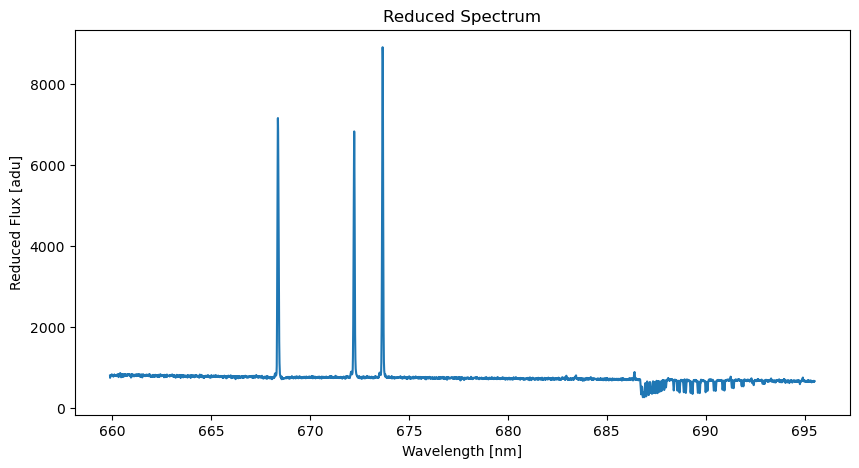

In [75]:
fits_path = data_folder + "/ADP.2019-01-31T23_21_56.029.fits"

with fits.open(fits_path) as hdul:
    spec = hdul[1].data
    hdr = hdul[0].header

    wave = spec["WAVE"][0]
    flux = spec["FLUX_REDUCED"][0]
    err  = spec["ERR_REDUCED"][0]
#    snr  = spec["SNR"][0]


plt.figure(figsize=(10, 5))
plt.plot(wave, flux)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
plt.title("Reduced Spectrum")
plt.show()